### LOADING AND CONFIGURATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import joblib
import os

DATA_PATH = r'D:\PJT2\CMAPSSData' 
PROCESSED_PATH = r'../../../processed_data'
RUL_CAP = 125 
WINDOW_SIZE = 60

if not os.path.exists(PROCESSED_PATH):
    os.makedirs(PROCESSED_PATH)

cols = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's{i}' for i in range(1, 22)]

print("Loading FD004 Raw Data...")
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_FD004.txt'), sep='\s+', header=None, names=cols)

Loading FD004 Raw Data...


### RUL CALCULATION

In [2]:
def add_rul(df):
    max_cycle = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycle.columns = ['unit_number', 'max_cycle']
    df = df.merge(max_cycle, on='unit_number', how='left')
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df = df.drop(columns=['max_cycle'])
    df['RUL'] = df['RUL'].clip(upper=RUL_CAP)
    return df

train_df = add_rul(train_df)

### OPERATING CONDITION NORMALISATION

In [3]:
setting_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols = [f's{i}' for i in range(1, 22)]

#Finding the 6 Flight Regimes
kmeans_op = KMeans(n_clusters=6, random_state=42, n_init=10)
train_df['op_cluster'] = kmeans_op.fit_predict(train_df[setting_cols])

#Calculating the Mean and Std for sensors IN EACH REGIME
regime_stats = train_df.groupby('op_cluster')[sensor_cols].agg(['mean', 'std'])

joblib.dump(kmeans_op, os.path.join(PROCESSED_PATH, 'fd004_op_kmeans.pkl'))
joblib.dump(regime_stats, os.path.join(PROCESSED_PATH, 'fd004_regime_stats.pkl'))

#Normalizing the sensors to strip away the altitude noise
norm_df = train_df.copy()
norm_df[sensor_cols] = norm_df[sensor_cols].astype('float64')

for regime in range(6):
    mask = norm_df['op_cluster'] == regime
    for col in sensor_cols:
        mean_val = regime_stats.loc[regime, (col, 'mean')]
        std_val = regime_stats.loc[regime, (col, 'std')]
        if std_val > 1e-6:
            norm_df.loc[mask, col] = (norm_df.loc[mask, col] - mean_val) / std_val
        else:
            norm_df.loc[mask, col] = 0.0

print("Altitude noise removed. Data is now purely physical degradation.")

Altitude noise removed. Data is now purely physical degradation.


### EXTRACTING SIGNATURE FOR ROUTER

In [4]:
print("\nExtracting True Fault Signatures...")
signatures = []
engine_ids = norm_df['unit_number'].unique()

for unit in engine_ids:
    engine_data = norm_df[norm_df['unit_number'] == unit]
    end_of_life = engine_data[sensor_cols].tail(5).mean().values
    signatures.append(end_of_life)

sig_df = pd.DataFrame(signatures, columns=sensor_cols)
stds = sig_df.std()
valid_sig_cols = stds[stds > 0].index.tolist()
sig_df_clean = sig_df[valid_sig_cols]

scaler_cluster = StandardScaler()
signatures_scaled = scaler_cluster.fit_transform(sig_df_clean)

# K-Means clusters the ACTUAL faults
kmeans_fault = KMeans(n_clusters=2, random_state=42, n_init=20)
fault_labels = kmeans_fault.fit_predict(signatures_scaled)

fault_mapping = pd.DataFrame({'unit_number': engine_ids, 'fault_mode': fault_labels})
print("\nTrue Engines assigned to Fault Modes:")
print(fault_mapping['fault_mode'].value_counts())

joblib.dump(scaler_cluster, os.path.join(PROCESSED_PATH, 'fd004_signature_scaler.pkl'))
joblib.dump(kmeans_fault, os.path.join(PROCESSED_PATH, 'fd004_router_model.pkl'))


Extracting True Fault Signatures...

True Engines assigned to Fault Modes:
fault_mode
1    148
0    101
Name: count, dtype: int64


['../../../processed_data\\fd004_router_model.pkl']

### FEATURE SCALING

In [5]:
print("\nPreparing LSTM Features (Using RAW Data!)...")
train_df = train_df.merge(fault_mapping, on='unit_number', how='left')

dataset_stds = train_df.describe().loc['std']
constant_features = dataset_stds[dataset_stds == 0].index.tolist()
drop_labels = constant_features + ['unit_number', 'time_in_cycles', 'RUL', 'fault_mode', 'op_cluster']
lstm_features = [c for c in train_df.columns if c not in drop_labels]

scaler = MinMaxScaler()
train_df[lstm_features] = scaler.fit_transform(train_df[lstm_features])

joblib.dump(scaler, os.path.join(PROCESSED_PATH, 'fd004_feature_scaler.pkl'))

# Proper Engine-Isolated Smoothing on the RAW train_df
train_df[lstm_features] = train_df.groupby('unit_number')[lstm_features].transform(lambda x: x.ewm(alpha=0.1).mean())


Preparing LSTM Features (Using RAW Data!)...


### SEQUENCE GENERATION

In [6]:
print(f"\nGenerating Specialist Datasets (Window Size = {WINDOW_SIZE})...")
def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    for start, stop in zip(range(0, num_elements-seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

def gen_labels(id_df, seq_length, label):
    data_matrix = id_df[label].values
    return data_matrix[seq_length:]

X_train_c0, y_train_c0 = [], []
X_train_c1, y_train_c1 = [], []

for unit_id in train_df['unit_number'].unique():
    unit_data = train_df[train_df['unit_number'] == unit_id]
    fault_type = unit_data['fault_mode'].iloc[0] 
    
    for seq in gen_sequence(unit_data, WINDOW_SIZE, lstm_features):
        if fault_type == 0: X_train_c0.append(seq)
        else: X_train_c1.append(seq)
            
    for label in gen_labels(unit_data, WINDOW_SIZE, 'RUL'):
        if fault_type == 0: y_train_c0.append(label)
        else: y_train_c1.append(label)

print(f"Cluster 0 Training Shape: {np.array(X_train_c0).shape}")
print(f"Cluster 1 Training Shape: {np.array(X_train_c1).shape}")


Generating Specialist Datasets (Window Size = 60)...
Cluster 0 Training Shape: (23610, 60, 24)
Cluster 1 Training Shape: (22699, 60, 24)


### SAVING

In [7]:
np.save(os.path.join(PROCESSED_PATH, 'X_train_FD004_c0.npy'), np.array(X_train_c0))
np.save(os.path.join(PROCESSED_PATH, 'y_train_FD004_c0.npy'), np.array(y_train_c0))
np.save(os.path.join(PROCESSED_PATH, 'X_train_FD004_c1.npy'), np.array(X_train_c1))
np.save(os.path.join(PROCESSED_PATH, 'y_train_FD004_c1.npy'), np.array(y_train_c1))

print("\nFD004 Specialist datasets successfully saved! Ready for modeling.")


FD004 Specialist datasets successfully saved! Ready for modeling.


### VISUALISING

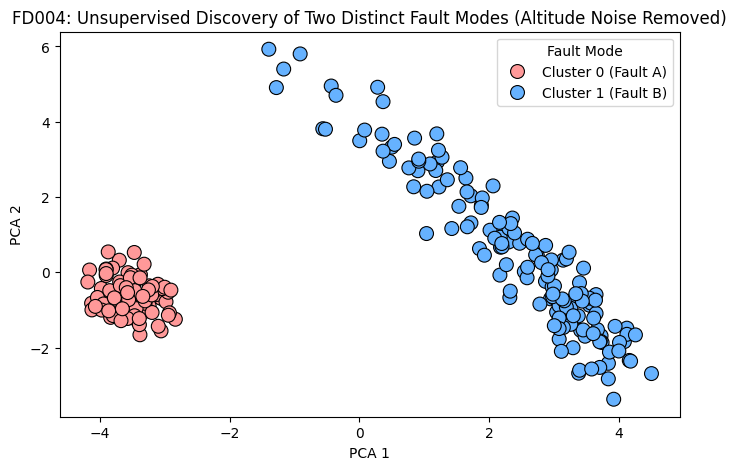

In [8]:
pca = PCA(n_components=2)
signatures_pca = pca.fit_transform(signatures_scaled)
pca_df = pd.DataFrame(signatures_pca, columns=['PCA 1', 'PCA 2'])
pca_df['Fault Mode'] = ['Cluster 0 (Fault A)' if x == 0 else 'Cluster 1 (Fault B)' for x in fault_labels]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x='PCA 1', y='PCA 2', hue='Fault Mode', palette=['#FF9999', '#66B2FF'], s=100, edgecolor='black')
plt.title('FD004: Unsupervised Discovery of Two Distinct Fault Modes (Altitude Noise Removed)')
plt.show()